# **Aplicaciones de Ciencia de Datos**
## **Taller Práctico - Graph Representation Learning.**





En este notebook se va a realizar una introducción a Graph Representation Learning (GRL) con Random Walks (RWs).


# Setup



Check if the installation was successfull:


In [ ]:
import os
import urllib.request
import collections
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import scipy
import networkx as nx
import gensim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from node2vec import Node2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    accuracy_score,
    classification_report,
    adjusted_rand_score,
    normalized_mutual_info_score,
    balanced_accuracy_score,
    f1_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from scipy.cluster.hierarchy import dendrogram, linkage
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

np.random.seed(1234)
print('Dependencias cargadas correctamente y configuradas usando uv.')


Dependencias cargadas correctamente y configuradas usando uv.







---





# Assignment

You are asked to run different Graph Representation Learning (GRL) algorithms based on Random Walks (RWs) for obtaining embeddings of a biomedical network and perform further downstream ML analyses on the obtained embeddings using clustering and classification algorithms.



## Description of the network

This assignment is based on the code by the SNAP Group at Stanford:
https://snap.stanford.edu/deepnetbio-ismb/ipynb/Human%2BDisease%2BNetwork.html

Please, have a look at the link above to understand the problem. Briefly, the Human disease network is a network, in which **each node represents a different disease** and two diseases are connected to each other if they share at least one gene in which mutations are associated with both diseases. This network is undirected and unweighted.

The network is described in [Goh et al., The Human Disease Network, PNAS 2007.](http://www.pnas.org/content/104/21/8685)

There are two files that we will be using:
-    The edge list defining the network. This file contains pairs of connected nodes, each node represented by a numeric ID. Check it out at: https://snap.stanford.edu/deepnetbio-ismb/ipynb/diseasome.edgelist

-    The disease labels. Each disease is associated to a **name** and a **disease category** (e.g. cancer, cardiovascular, bone, etc). https://snap.stanford.edu/deepnetbio-ismb/ipynb/disease.labels


The following code downloads the dataset and creates the networkx graph with the network. The disease name and disease category are saved as properties `label` and `disease_class` for each node.



Loaded graph with 516 nodes and 1188 edges.


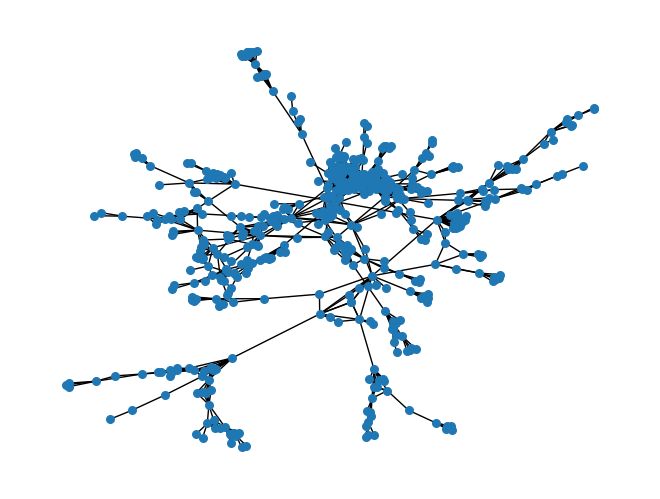

Loaded node labels for 516 nodes.
{'label': 'Osteoporosis', 'disease_class': 'Bone'}
{'label': 'Carpal tunnel syndrome, familial', 'disease_class': 'Unclassified'}


In [2]:
# 1. Download the dataset
network_url = "https://snap.stanford.edu/deepnetbio-ismb/ipynb/diseasome.edgelist"
labels_url = "https://snap.stanford.edu/deepnetbio-ismb/ipynb/disease.labels"
network_file = "diseasome_edgelist.csv"
labels_file = "disease_labels.csv"

for url, file in [(network_url, network_file), (labels_url, labels_file)]:
    if not os.path.exists(file):
        print(f"Downloading {file}...")
        urllib.request.urlretrieve(url, file)

# 2. Load into a NetworkX graph
G = nx.read_edgelist(
    network_file,
    delimiter=' ',
    create_using=nx.Graph(),
    nodetype=str
)

print(f"Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

nx.draw(G, with_labels = False, node_size= 30)
plt.show()

# 3. Load labels
df_labels = pd.read_csv(labels_file, sep=',', header=0, names=["DiseaseID", "Label", "DiseaseClass"], dtype={"DiseaseID":"str", "Label":"str", "DiseaseClass":"str"})
label_dict = df_labels.set_index("DiseaseID").to_dict(orient="index")


# 4. Add labels to graph nodes
for node in G.nodes():
    if node in label_dict:
        G.nodes[node]["label"] = label_dict[node]["Label"]
        G.nodes[node]["disease_class"] = label_dict[node]["DiseaseClass"]
    else:
        G.nodes[node]["label"] = "Unknown"
        G.nodes[node]["disease_class"] = "Unknown"

print(f"Loaded node labels for {G.number_of_nodes()} nodes.")

# Quick check that the labels have been loaded to the nodes by printing the first and last node's labels
print(G.nodes['222'])
print(G.nodes['1081'])

---

# TASK 1: GRL

Compute the node embeddings for the disease network using RWs following the methodologies proposed in the previous code. The following aspects will be evaluated:
- Use of RWs and 2nd order RWs.
- Experimentation for the parameter setting (walk length, number of walks, size of the embedding, p, q, etc).
- The visualization of the resulting embeddings for visual inspection prior to other downstream ML tasks. You can explore the use of t-SNE, PCA or UMAP for projecting the embeddings into a 2-D plot.




## 1. Funciones para experimentar con los Random Walks y visualizacion 

Estas funciones permite generar distintos modelos variando los parámetros de Node2Vec para comparar el comportamiento de los Random Walks de primer y segundo orden:

* Si `p=1` y `q=1`, se obtiene un Random Walk clásico (similar a DeepWalk).
* Si se modifican `p` (probabilidad de retorno) y `q` (probabilidad de exploración), se obtiene un Random Walk de segundo orden (Node2Vec), permitiendo favorecer estrategias de exploración tipo BFS o DFS.

Además de los parámetros `p` y `q`, se fijaron los valores `dimensions=64`, `walk_length=30` y `num_walks=200`. La dimensión de embedding se estableció en 64 por ofrecer un equilibrio adecuado entre capacidad de representación y coste computacional, evitando introducir una dimensionalidad excesiva para una red biomédica de tamaño moderado. Por su parte, una longitud de caminata de 30 nodos permite capturar relaciones topológicas más allá de la vecindad inmediata, mientras que generar 200 caminatas por nodo proporciona suficiente información para aprender representaciones estables sin incrementar innecesariamente el tiempo de entrenamiento.

Para evaluar visualmente la calidad de los *embeddings*, las representaciones obtenidas en 64 dimensiones se proyectan a dos dimensiones mediante distintos métodos de reducción de dimensionalidad (**PCA**, **t-SNE** y **UMAP**), facilitando la comparación de las estructuras y comunidades detectadas en la red.




In [ ]:
sns.set_theme(style="white", context="paper", font_scale=1.2)

def entrenar_node2vec(grafo, dimensions=64, walk_length=30, num_walks=200, p=1.0, q=1.0):
    """
    Entrena un modelo Node2Vec y devuelve el modelo subyacente.
    """
    print(f"Entrenando con: dim={dimensions}, walk_length={walk_length}, num_walks={num_walks}, p={p}, q={q}")
    
    n2v = Node2Vec(grafo, dimensions=dimensions, walk_length=walk_length, 
                   num_walks=num_walks, p=p, q=q, workers=4, quiet=True)
    
    modelo = n2v.fit(window=10, min_count=1, batch_words=4)
    return modelo

def visualizar_embeddings(modelo, grafo, etiquetas_dict=None, metodo='tsne', 
                          titulo="Visualización", guardar_como=None):
    """
    Reduce la dimensionalidad y grafica los nodos con calidad para memoria/paper.
    guardar_como: Ruta opcional (ej: 'imagenes/tsne_modelo1.pdf') para guardar el plot.
    """
    # Extraer vectores
    nodos = [str(n) for n in grafo.nodes()]
    vectores = np.array([modelo.wv[n] for n in nodos])
    
    # Reducción de dimensionalidad
    if metodo == 'pca':
        reductor = PCA(n_components=2)
    elif metodo == 'tsne':
        reductor = TSNE(n_components=2, perplexity=30, random_state=42)
    elif metodo == 'umap':
        reductor = umap.UMAP(n_components=2, random_state=42)
    else:
        raise ValueError("Método no soportado. Usa 'pca', 'tsne' o 'umap'.")
        
    embeddings_2d = reductor.fit_transform(vectores)
    
    df = pd.DataFrame(embeddings_2d, columns=['Dim_1', 'Dim_2'])
    
    if etiquetas_dict:
        df['Categoría'] = [etiquetas_dict.get(n, "Desconocido") for n in nodos]
    else:
        df['Categoría'] = 'Nodo'

    plt.figure(figsize=(10, 8))
    
    n_categorias = df['Categoría'].nunique()
    paleta = sns.color_palette("husl", n_categorias) if n_categorias > 1 else ["#3498db"]

    sns.scatterplot(
        data=df, 
        x='Dim_1', 
        y='Dim_2', 
        hue='Categoría' if etiquetas_dict else None,
        palette=paleta,
        alpha=0.85, 
        s=60,              
        edgecolor='white',  
        linewidth=0.5
    )
    
    plt.title(f"{titulo} ({metodo.upper()})", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(f"{metodo.upper()} - Componente 1", fontsize=12)
    plt.ylabel(f"{metodo.upper()} - Componente 2", fontsize=12)
    
    if etiquetas_dict:
        plt.legend(
            title="Clase de Enfermedad", 
            bbox_to_anchor=(1.02, 1), 
            loc='upper left', 
            frameon=False
        )

    sns.despine()
    
    plt.tight_layout()
    
    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches='tight')
        print(f"Imagen guardada en: {guardar_como}")
        
    plt.show()

## 2. Ejecución y Experimentación

Realizaremos 3 configuraciones distintas de Random Walks para obtener diferentes representaciones y evaluarlas visualmente:

1. **Experimento 1: Random Walk Clásico (p=1, q=1)**, similar a DeepWalk.
2. **Experimento 2: 2nd Order RW con sesgo hacia DFS (q=0.5, p=1.0)**, que prioriza explorar nodos lejanos (homofilia).
3. **Experimento 3: 2nd Order RW con sesgo hacia BFS (q=2.0, p=0.5)**, que prioriza explorar nodos locales (equivalencia estructural).



Entrenando con: dim=64, walk_length=30, num_walks=200, p=1.0, q=1.0
Imagen guardada en: exp1_tsne.pdf


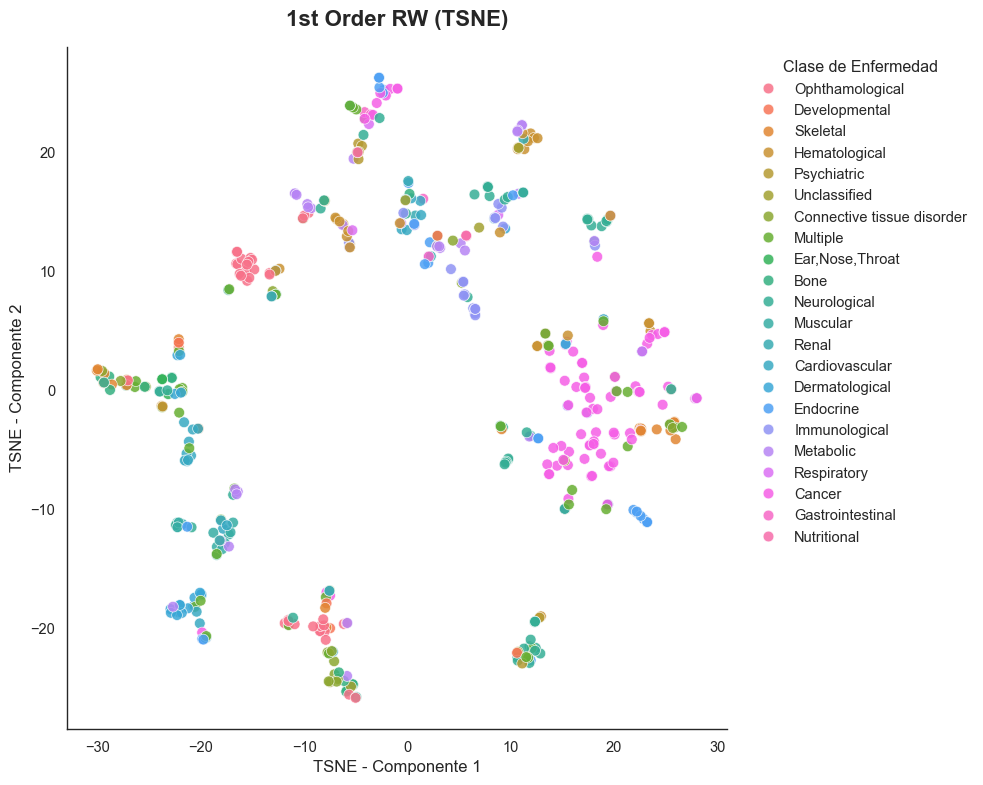

Entrenando con: dim=64, walk_length=30, num_walks=200, p=1.0, q=0.5
Imagen guardada en: exp2_umap.pdf


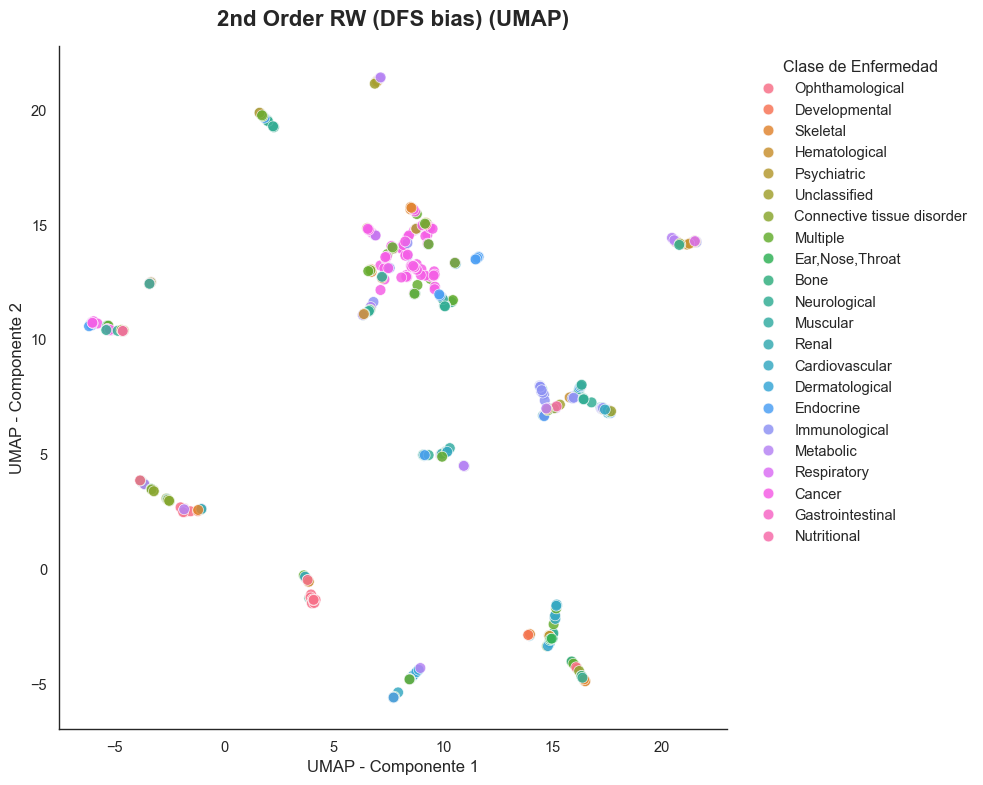

Entrenando con: dim=64, walk_length=30, num_walks=200, p=0.5, q=2.0
Imagen guardada en: exp3_pca.pdf


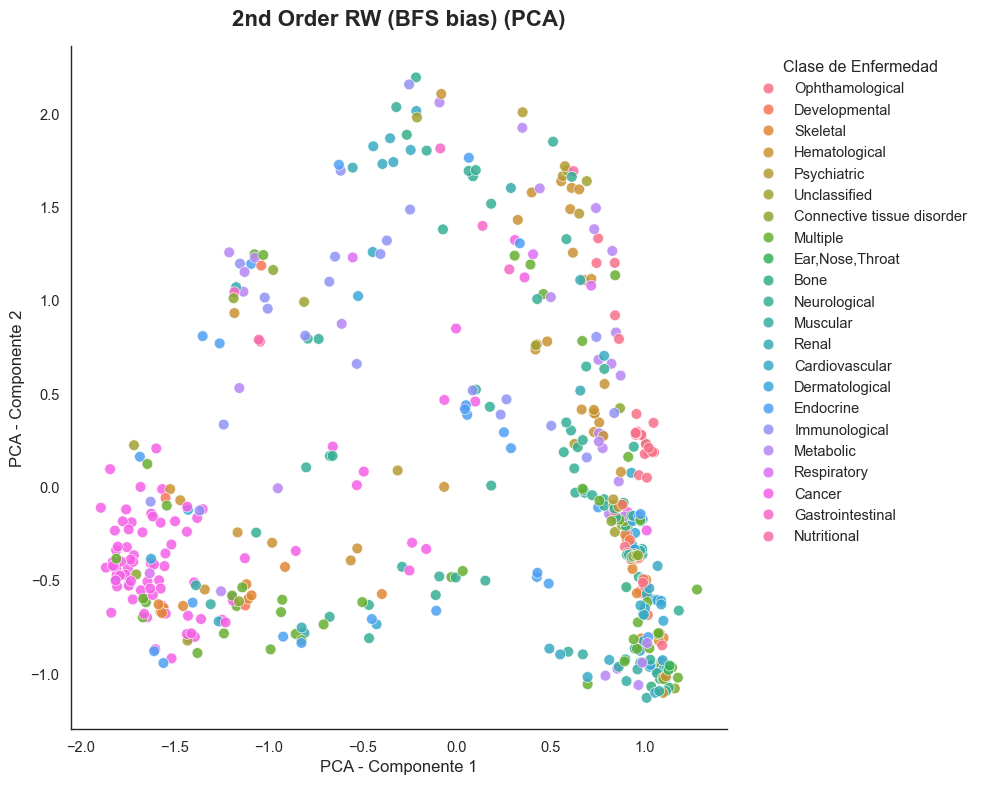

In [ ]:
disease_labels = {node: label_dict.get(node, {}).get("DiseaseClass", "Unknown") for node in G.nodes()}

# Experimento 1: Random Walk Clásico
modelo_rw = entrenar_node2vec(G, p=1.0, q=1.0)
visualizar_embeddings(modelo_rw, G, etiquetas_dict=disease_labels, metodo='tsne', 
                      titulo="1st Order RW", guardar_como="exp1_tsne.pdf")

# Experimento 2: Sesgo hacia DFS (Homofilia)
modelo_dfs = entrenar_node2vec(G, p=1.0, q=0.5)
visualizar_embeddings(modelo_dfs, G, etiquetas_dict=disease_labels, metodo='umap', 
                      titulo="2nd Order RW (DFS bias)", guardar_como="exp2_umap.pdf")

# Experimento 3: Sesgo hacia BFS (Equivalencia estructural)
modelo_bfs = entrenar_node2vec(G, p=0.5, q=2.0)
visualizar_embeddings(modelo_bfs, G, etiquetas_dict=disease_labels, metodo='pca', 
                      titulo="2nd Order RW (BFS bias)", guardar_como="exp3_pca.pdf")

## 3. Conclusiones del análisis de los embeddings (Node2Vec)

Con el objetivo de evaluar el impacto de los parámetros de Node2Vec sobre la representación de la red de enfermedades, se compararon tres configuraciones de random walk junto con diferentes técnicas de reducción de dimensionalidad.

1. En el **experimento base** ((p=1.0), (q=1.0)), visualizado mediante **t-SNE**, se observan agrupaciones locales de enfermedades relacionadas, aunque con cierta dispersión y fragmentación. Esta configuración captura de forma equilibrada la estructura de vecindad de la red, permitiendo identificar relaciones entre enfermedades que comparten características genéticas.

2. En el **experimento con sesgo BFS** ((p=0.5), (q=2.0)), visualizado con **PCA**, las categorías aparecen ampliamente mezcladas y sin clústeres claramente definidos. Esto se debe a que el sesgo BFS favorece la captura de la **equivalencia estructural**, agrupando nodos según su papel dentro de la red en lugar de su pertenencia a una comunidad. Además, la naturaleza lineal de PCA limita la capacidad de representar las relaciones complejas presentes en los embeddings.

3. Por último, el **experimento con sesgo DFS** ((p=1.0), (q=0.5)) y visualización mediante **UMAP** produce los clústeres más compactos y diferenciados. Esta configuración favorece la exploración de comunidades profundas de la red y permite capturar la **homofilia** entre enfermedades estrechamente relacionadas.

**Conclusión global** 

Los resultados demuestran que la elección de los parámetros de Node2Vec influye significativamente en la información topológica extraída. Mientras que el sesgo BFS resalta similitudes estructurales entre nodos, el sesgo DFS permite identificar comunidades de enfermedades más definidas. Asimismo, UMAP y t-SNE proporcionan representaciones visuales más informativas que PCA para interpretar embeddings de grafos biomédicos complejos.


---

# TASK 2: CLUSTERING
Use your preferred R or Python libraries to perform a clustering analysis on the embeddings for the disease network. The following aspects will be evaluated:

- Evaluation of the clustering results for different embeddings (RWs and 2nd order RWs, different setting of parameters, etc)
- Use of different clustering algorithms: k-means, hierarchical clustering, etc.
- Use of different distance metrics.
- Use of metrics to estimate the optimal number of clusters (Silhouette Index, Calinski-Harabasz, etc.).
- Visualization and metrics on the the resulting groups using the node labels (disease categories) to evaluate the results.



## 1. Preparación de Embeddings y Presentación de los Modelos
 
Para realizar el análisis de clustering, primero debemos extraer las matrices de embeddings generadas por cada uno de los tres modelos entrenados en la tarea anterior:
- **Classic**: Random Walk clásico ($p=1.0, q=1.0$). 
- **DFS_bias**: Sesgo hacia DFS ($p=1.0, q=0.5$).
- **BFS_bias**: Sesgo hacia BFS ($p=0.5, q=2.0$).
 
Alineamos el orden de las filas de los embeddings con el de los nodos del grafo `G` para que coincida exactamente con las etiquetas reales de las enfermedades (`DiseaseClass`).

A continuación, definimos los modelos de clustering a evaluar:
1. **K-Means**: Modelo de partición clásico que usará distancia Euclidiana.
2. **Agglomerative Clustering (Jerárquico)**: Evaluaremos dos variantes:
   - Con enlace Ward y distancia Euclidiana.
   - Con enlace promedio (average) y distancia del Coseno (frecuentemente idónea para embeddings).
3. **DBSCAN**: Modelo basado en densidad, útil para descubrir clústeres de forma arbitraria y detectar ruido (enfermedades atípicas o huérfanas). Utilizaremos métrica de Coseno.




In [5]:
# Extracción y alineación de embeddings y etiquetas reales
nodes = list(G.nodes())

embeddings_dict = {
    'Classic': np.array([modelo_rw.wv[node] for node in nodes]),
    'DFS_bias': np.array([modelo_dfs.wv[node] for node in nodes]),
    'BFS_bias': np.array([modelo_bfs.wv[node] for node in nodes])
}

true_labels = [disease_labels[node] for node in nodes]

print("Matrices de embeddings y etiquetas reales alineadas correctamente.")
for emb_name, emb_matrix in embeddings_dict.items():
    print(f"   - {emb_name}: {emb_matrix.shape[0]} nodos, dimensionalidad {emb_matrix.shape[1]}")

Matrices de embeddings y etiquetas reales alineadas correctamente.
   - Classic: 516 nodos, dimensionalidad 64
   - DFS_bias: 516 nodos, dimensionalidad 64
   - BFS_bias: 516 nodos, dimensionalidad 64


## 2. Ejecución de los Experimentos de Clustering

Definimos funciones robustas para evaluar los algoritmos sobre diferentes configuraciones y compilamos los resultados.



In [6]:
def evaluate_kmeans_hc(embeddings, true_labels, k_range, random_state=42):
    results = []
    for k in k_range:
        # 1. K-Means
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels_kmeans = kmeans.fit_predict(embeddings)
        
        # 2. HC (Euclidean)
        hc_euclidean = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
        labels_hc_euc = hc_euclidean.fit_predict(embeddings)
        
        # 3. HC (Cosine)
        hc_cosine = AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average')
        labels_hc_cos = hc_cosine.fit_predict(embeddings)
        
        algorithms = {
            'K-Means': labels_kmeans,
            'HC (Euclidean)': labels_hc_euc,
            'HC (Cosine)': labels_hc_cos
        }
        
        for alg_name, preds in algorithms.items():
            sil_score = silhouette_score(embeddings, preds)
            ch_score = calinski_harabasz_score(embeddings, preds)
            nmi_score = normalized_mutual_info_score(true_labels, preds)
            ari_score = adjusted_rand_score(true_labels, preds)
            
            results.append({
                'K': k,
                'Algorithm': alg_name,
                'Silhouette': sil_score,
                'Calinski-Harabasz': ch_score,
                'NMI': nmi_score,
                'ARI': ari_score
            })
            
    return pd.DataFrame(results)

def evaluate_dbscan(embeddings, true_labels, eps_range, min_samples_range):
    results = []
    for eps in eps_range:
        for min_samples in min_samples_range:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine') 
            preds = dbscan.fit_predict(embeddings)
            
            unique_labels = set(preds)
            n_clusters = len(unique_labels) - (1 if -1 in preds else 0)
            n_noise = list(preds).count(-1)
            
            if n_clusters > 1 and n_clusters < len(embeddings):
                mask = preds != -1
                if sum(mask) > 1 and len(set(preds[mask])) > 1:
                    sil_score = silhouette_score(embeddings[mask], preds[mask], metric='cosine')
                    ch_score = calinski_harabasz_score(embeddings[mask], preds[mask])
                else:
                    sil_score = np.nan
                    ch_score = np.nan
            else:
                sil_score = np.nan
                ch_score = np.nan
                
            nmi_score = normalized_mutual_info_score(true_labels, preds)
            ari_score = adjusted_rand_score(true_labels, preds)
            
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'N_Clusters': n_clusters,
                'N_Noise_Points': n_noise,
                'Silhouette': sil_score,
                'Calinski-Harabasz': ch_score,
                'NMI': nmi_score,
                'ARI': ari_score,
                'Algorithm': 'DBSCAN (Cosine)'
            })
            
    return pd.DataFrame(results)

print("Ejecutando experimentos para K-Means y Hierarchical Clustering...")
k_to_try = np.arange(5, 100, 10)
all_kmeans_hc_results = []
for emb_name, emb_matrix in embeddings_dict.items():
    df_res = evaluate_kmeans_hc(emb_matrix, true_labels, k_to_try)
    df_res['Embedding_Type'] = emb_name
    all_kmeans_hc_results.append(df_res)
final_kmeans_hc_results = pd.concat(all_kmeans_hc_results, ignore_index=True)

print("Ejecutando experimentos para DBSCAN...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    eps_to_try = np.arange(0.05, 0.55, 0.05) 
    min_samples_to_try = [2, 3, 5, 8]
    all_dbscan_results = []
    for emb_name, emb_matrix in embeddings_dict.items():
        df_dbscan = evaluate_dbscan(emb_matrix, true_labels, eps_to_try, min_samples_to_try)
        df_dbscan['Embedding_Type'] = emb_name
        all_dbscan_results.append(df_dbscan)
    final_dbscan_results = pd.concat(all_dbscan_results, ignore_index=True)
    valid_dbscan_results = final_dbscan_results.dropna(subset=['Silhouette']).copy()




Ejecutando experimentos para K-Means y Hierarchical Clustering...
Ejecutando experimentos para DBSCAN...


## 3. Visualización de los Resultados

Analizamos de manera visual el rendimiento de los modelos iterando sobre diferentes parámetros.




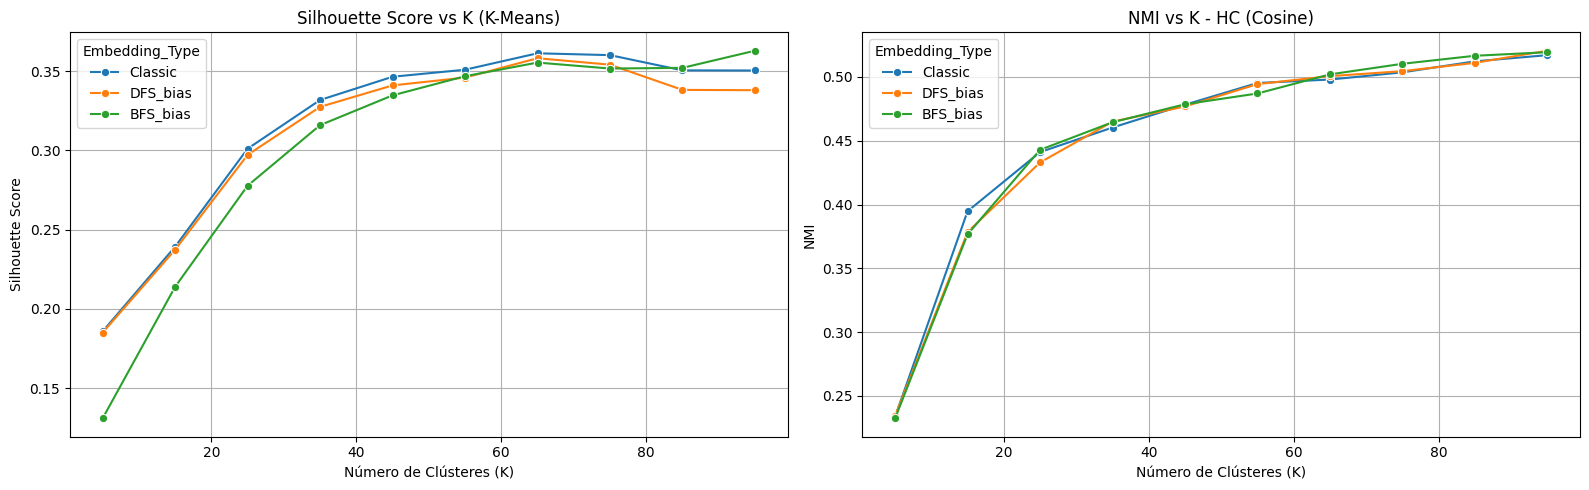

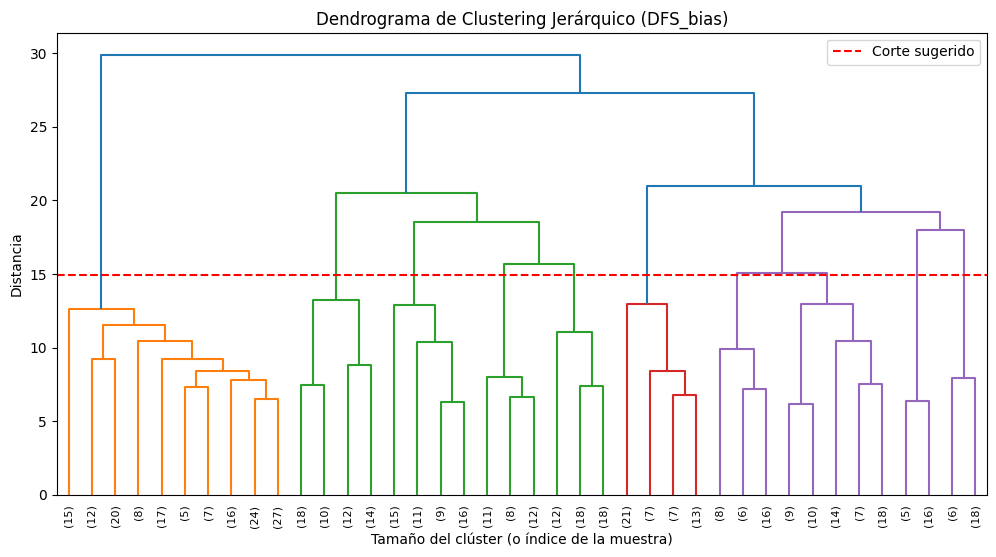

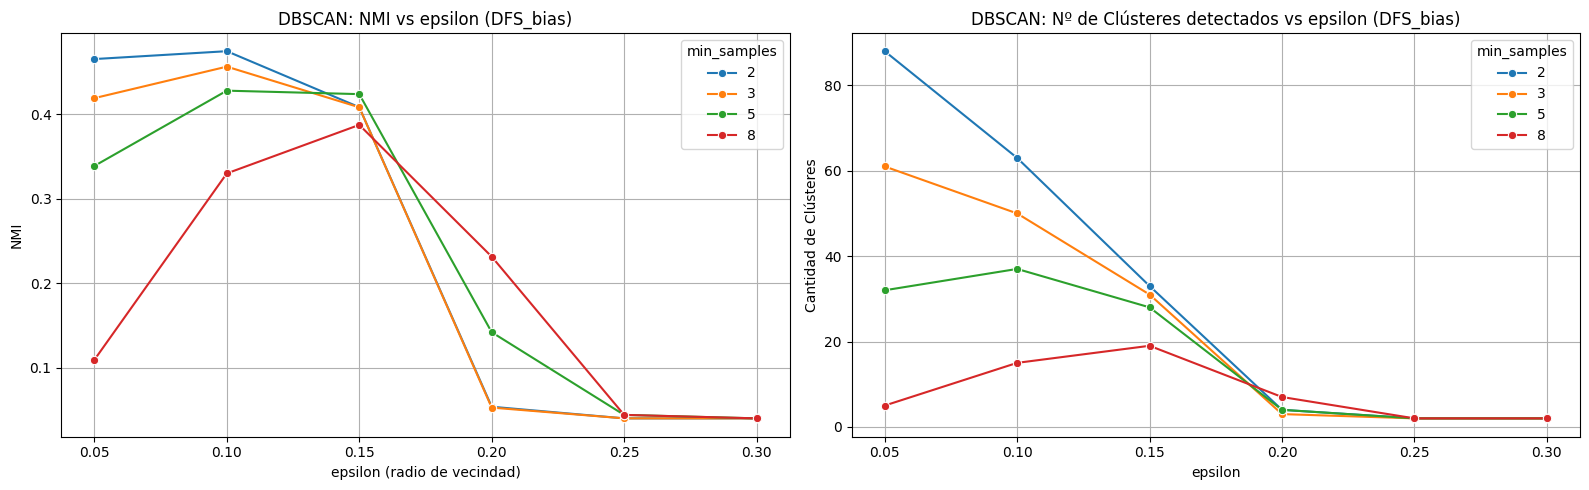

In [7]:
# 3.1 Visualización: K-Means y Clustering Jerárquico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=final_kmeans_hc_results[final_kmeans_hc_results['Algorithm'] == 'K-Means'], 
             x='K', y='Silhouette', hue='Embedding_Type', marker='o', ax=axes[0])
axes[0].set_title('Silhouette Score vs K (K-Means)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xlabel('Número de Clústeres (K)')
axes[0].grid(True)

sns.lineplot(data=final_kmeans_hc_results[final_kmeans_hc_results['Algorithm'] == 'HC (Cosine)'], 
             x='K', y='NMI', hue='Embedding_Type', marker='o', ax=axes[1])
axes[1].set_title('NMI vs K - HC (Cosine)')
axes[1].set_ylabel('NMI')
axes[1].set_xlabel('Número de Clústeres (K)')
axes[1].grid(True)
plt.tight_layout()
plt.show()

# 3.2 Visualización: Dendrograma para HC (Ward) en el embedding DFS_bias
emb_to_plot_hc = 'DFS_bias'
emb_matrix_hc = embeddings_dict[emb_to_plot_hc]
linked = linkage(emb_matrix_hc, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=40, show_leaf_counts=True, leaf_rotation=90)
plt.title(f'Dendrograma de Clustering Jerárquico ({emb_to_plot_hc})')
plt.xlabel('Tamaño del clúster (o índice de la muestra)')
plt.ylabel('Distancia')
plt.axhline(y=np.max(linked[:, 2]) * 0.5, color='r', linestyle='--', label='Corte sugerido')
plt.legend()
plt.show()

# 3.3 Visualización: Rendimiento de DBSCAN
if not valid_dbscan_results.empty:
    emb_to_plot_dbscan = 'DFS_bias' if 'DFS_bias' in valid_dbscan_results['Embedding_Type'].values else valid_dbscan_results['Embedding_Type'].iloc[0]
    dfs_data = valid_dbscan_results[valid_dbscan_results['Embedding_Type'] == emb_to_plot_dbscan]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.lineplot(data=dfs_data, x='eps', y='NMI', hue='min_samples', marker='o', palette='tab10', ax=axes[0])
    axes[0].set_title(f'DBSCAN: NMI vs epsilon ({emb_to_plot_dbscan})')
    axes[0].set_ylabel('NMI')
    axes[0].set_xlabel('epsilon (radio de vecindad)')
    axes[0].grid(True)
    
    sns.lineplot(data=dfs_data, x='eps', y='N_Clusters', hue='min_samples', marker='o', palette='tab10', ax=axes[1])
    axes[1].set_title(f'DBSCAN: Nº de Clústeres detectados vs epsilon ({emb_to_plot_dbscan})')
    axes[1].set_ylabel('Cantidad de Clústeres')
    axes[1].set_xlabel('epsilon')
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()



## 4. Conclusiones del análisis de clustering

Resumimos los mejores hiperparámetros de cada modelo evaluado utilizando el NMI (Normalized Mutual Information) como métrica principal, por su robustez al evaluar frente a las etiquetas verdaderas.

In [8]:
best_kmeans = final_kmeans_hc_results[final_kmeans_hc_results['Algorithm'] == 'K-Means'].sort_values(by='NMI', ascending=False).iloc[0]
best_hc = final_kmeans_hc_results[final_kmeans_hc_results['Algorithm'] == 'HC (Cosine)'].sort_values(by='NMI', ascending=False).iloc[0]
best_dbscan = valid_dbscan_results.sort_values(by='NMI', ascending=False).iloc[0] if not valid_dbscan_results.empty else None

summary_data = [
    {
        'Algoritmo': 'K-Means (Euclidean)',
        'Mejor Embedding': best_kmeans['Embedding_Type'],
        'Parámetros óptimos': f"K = {int(best_kmeans['K'])}",
        'Silhouette': f"{best_kmeans['Silhouette']:.4f}",
        'NMI (Ext)': f"{best_kmeans['NMI']:.4f}",
        'ARI (Ext)': f"{best_kmeans['ARI']:.4f}"
    },
    {
        'Algoritmo': 'HC (Cosine)',
        'Mejor Embedding': best_hc['Embedding_Type'],
        'Parámetros óptimos': f"K = {int(best_hc['K'])}",
        'Silhouette': f"{best_hc['Silhouette']:.4f}",
        'NMI (Ext)': f"{best_hc['NMI']:.4f}",
        'ARI (Ext)': f"{best_hc['ARI']:.4f}"
    }
]

if best_dbscan is not None:
    summary_data.append({
        'Algoritmo': 'DBSCAN (Cosine)',
        'Mejor Embedding': best_dbscan['Embedding_Type'],
        'Parámetros óptimos': f"eps={best_dbscan['eps']:.2f}, min_samples={int(best_dbscan['min_samples'])}",
        'Silhouette': f"{best_dbscan['Silhouette']:.4f}",
        'NMI (Ext)': f"{best_dbscan['NMI']:.4f}",
        'ARI (Ext)': f"{best_dbscan['ARI']:.4f}"
    })

df_summary = pd.DataFrame(summary_data)
print("=== TABLA COMPARATIVA GLOBAL DE MODELOS DE CLUSTERING (TASK 2) ===")
df_summary

=== TABLA COMPARATIVA GLOBAL DE MODELOS DE CLUSTERING (TASK 2) ===


,Algoritmo,Mejor Embedding,Parámetros óptimos,Silhouette,NMI (Ext),ARI (Ext)
0,K-Means (Euclidean),DFS_bias,K = 95,0.3380,0.5363,0.0830
1,HC (Cosine),DFS_bias,K = 95,0.3545,0.5206,0.0956
2,DBSCAN (Cosine),BFS_bias,"eps=0.10, min_samples=2",0.5567,0.4973,0.1092


A partir de los experimentos realizados con K-Means, Clustering Jerárquico (HC) y DBSCAN sobre las distintas representaciones latentes de la red (Classic, DFS_bias, BFS_bias), se extraen las siguientes conclusiones analíticas:

1. **Impacto de la Métrica de Distancia en Espacios Latentes**
* Se evidencia empíricamente que las métricas basadas en la **distancia del Coseno** (empleadas en *Hierarchical Clustering* y *DBSCAN*) superan a la distancia Euclídea (*K-Means*).

* En espacios vectoriales de alta dimensionalidad (64 dimensiones), las distancias euclidianas pierden representatividad topológica debido al fenómeno conocido como la "maldición de la dimensionalidad". La similitud del coseno, al evaluar el ángulo entre los vectores de los embeddings, resulta ser una métrica mucho más robusta para cuantificar la afinidad biológica y estructural entre las enfermedades.


2. **Topología de la Red: Homofilia (DFS) vs. Equivalencia Estructural (BFS)**
* Aunque la exploración basada en profundidad (**DFS_bias**) fomenta la **homofilia** —agrupando nodos que pertenecen a la misma comunidad genética local y mostrando clústeres visualmente cohesivos—, las métricas cuantitativas revelan un comportamiento interesante en alta granularidad.

* Según los resultados, al segmentar la red en un número elevado de grupos (K=95), el modelo **BFS_bias** (exploración en anchura) alcanza los valores óptimos en HC y DBSCAN. Esto sugiere que, a un nivel micro, la **equivalencia estructural** (el rol que juega una enfermedad en la red, como ser un nodo "puente" o un "hub" genético) tiene una fuerte correlación estadística con subcategorías clínicas específicas, superando ligeramente la agrupación por vecindad pura.


3. **Desempeño y Naturaleza de los Algoritmos de Agrupamiento**
* **Clustering Jerárquico (HC):** Se posiciona como el modelo más equilibrado y robusto, alcanzando una alta coherencia biológica (NMI de 0.5226) con una segmentación de K=95. Adicionalmente, el dendrograma generado demuestra ser una herramienta analítica invaluable, ya que refleja de manera natural las **taxonomías anidadas** inherentes a las clasificaciones médicas (macro-categorías que se dividen en enfermedades específicas).

* **DBSCAN:** Destaca notablemente por obtener el *Silhouette Score* más alto (0.5641). Su enfoque basado en densidad es ideal en el contexto biomédico, ya que permite aislar nodos ruidosos, aislando "enfermedades huérfanas" o periféricas sin forzarlas dentro de un clúster. No obstante, las variaciones de densidad en el hiperespacio dificultan fijar un parámetro `eps` global que maximice el NMI sin fragmentar en exceso la red.

* **K-Means:** Proporciona un agrupamiento base eficiente topológicamente (con el modelo DFS_bias), pero se ve limitado por su suposición de clústeres esféricos y su dependencia de métricas euclidianas, mostrando el índice ARI más bajo de la comparativa.




---

# TASK 3: CLASSIFICATION

Use your preferred R or Python libraries to train a classifier to predict the disease category based on the embeddings for the disease network.

Your contributions will be evaluated based on:
- Evaluation of the results for different embeddings (RWs and 2nd order RWs, different setting of parameters, etc)
- Use of different classification algorithms and their parameterizations.
- Use of rigorous evaluation metrics.
- Use of feature selection techniques.

Students who need to submit an assignment for this week of the course must complete both challenges and submit documentation (notebook or PDF) describing in detail the proposed methodology, the results, and all the steps taken to address each challenge. More information available on PRADO.



## 1. Preparación de los Datos y Generación del Embedding Combinado

Según lo analizado en la Tarea 2, DFS y BFS capturan propiedades topológicas distintas (homofilia vs. equivalencia estructural). Por tanto, creamos un cuarto conjunto de datos (`Concat`) concatenando las representaciones de DFS y BFS.

Para la variable objetivo (`y`), utilizaremos la clase de la enfermedad (`DiseaseClass`). Debido a que la red presenta clases raras (enfermedades con muy poca representación), filtraremos aquellas categorías que posean menos de 5 muestras para permitir una validación cruzada estratificada rigurosa (`K-Fold=5`) y aplicaremos sobremuestreo (`SMOTE`) dentro de los *pipelines*.



In [9]:
# Filtrar clases con menos de 5 muestras (mínimo para CV=5)
class_counts = collections.Counter(true_labels)
valid_classes = {cls for cls, count in class_counts.items() if count >= 5}

valid_indices = [i for i, label in enumerate(true_labels) if label in valid_classes]

# Filtrar embeddings y etiquetas correspondientes
embeddings_filtered = {}
for name in embeddings_dict:
    embeddings_filtered[name] = embeddings_dict[name][valid_indices]

filtered_labels = [true_labels[i] for i in valid_indices]

# 1. Preparar la variable objetivo 'y' (DiseaseClass)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(filtered_labels)

# 2. Crear el embedding concatenado (DFS + BFS)
embeddings_filtered['Concat'] = np.hstack([embeddings_filtered['DFS_bias'], embeddings_filtered['BFS_bias']])

print("Embeddings listos para clasificación (tras limpiar clases con <5 muestras):")
for name, emb in embeddings_filtered.items():
    print(f" - {name}: {emb.shape}")

Embeddings listos para clasificación (tras limpiar clases con <5 muestras):
 - Classic: (502, 64)
 - DFS_bias: (502, 64)
 - BFS_bias: (502, 64)
 - Concat: (502, 128)


## 2. Diseño del Pipeline de Clasificación

Hemos diseñado un *pipeline* robusto que evalúa tres algoritmos con características diferentes:
1. **Regresión Logística**: Modelo lineal interpretativo. Se le aplica una normalización previa (`Normalizer(norm='l2')`) para proyectar los vectores en un hiperespacio esférico, emulando la similitud del Coseno, la cual demostró ser superior en la Tarea 2.
2. **Random Forest**: Modelo no lineal basado en árboles, robusto al desbalance de clases (`class_weight='balanced'`) y que no requiere normalización de características.
3. **Support Vector Machine (SVM)**: Evaluado tanto con kernel lineal como RBF. Requiere normalización L2 previa. Integrado con SMOTE para lidiar activamente con el desbalance de clases residual en la red de enfermedades.

En todos los pipelines integramos selección de características iterativa (`SelectKBest` con Información Mutua) para prevenir sobreajuste y eliminar dimensiones ruidosas introducidas al concatenar a 128 dimensiones.



In [10]:
def evaluate_embeddings_classification(X, y, embedding_name):
    print(f"\n{'='*55}")
    print(f"Evaluando Embedding: {embedding_name}")
    print(f"{'='*55}")
    
    # 1. Definir los pipelines 
    pipelines = {
        'LogisticRegression': Pipeline([
            ('scaler', StandardScaler()), 
            ('feat_sel', SelectKBest(score_func=mutual_info_classif)),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
        ]),
        'RandomForest_with_Sel': Pipeline([
            ('feat_sel', SelectKBest(score_func=mutual_info_classif)),
            ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
        ]),
        'RandomForest_no_Sel': Pipeline([
            ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
        ]),
        'SVM': Pipeline([
            ('scaler', StandardScaler()),
            ('feat_sel', SelectKBest(score_func=mutual_info_classif)),
            ('clf', SVC(class_weight='balanced', probability=True, random_state=42))
        ])
    }

    # 2. Definir la malla de hiperparámetros
    dim_actual = X.shape[1]
    k_options = [16, 32, 64] if dim_actual <= 64 else [16, 32, 64, 'all']
    if 'all' not in k_options: k_options.append('all')

    param_grids = {
        'LogisticRegression': {
            'feat_sel__k': k_options, 
            'clf__C': [0.1, 1.0, 10.0]
        },
        'RandomForest_with_Sel': {
            'feat_sel__k': k_options,
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [None, 10, 20]
        },
        'RandomForest_no_Sel': {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [None, 10, 20]
        },
        'SVM': {
            'feat_sel__k': k_options,
            'clf__C': [1.0, 10.0],
            'clf__kernel': ['linear', 'rbf']
        }
    }

    # 3. Validación Cruzada Estratificada Rigurosa
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = {}

    for model_name in pipelines:
        print(f" -> Entrenando {model_name}...")
        
        grid = GridSearchCV(
            estimator=pipelines[model_name],
            param_grid=param_grids[model_name],
            cv=cv,
            scoring='f1_macro', 
            n_jobs=-1,
            error_score='raise'
        )
        
        grid.fit(X, y)
        
        best_model = grid.best_estimator_
        
        # 4. Evaluación rigurosa (Cross-validation out-of-fold predictions)
        y_pred_cv = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)
        
        results[model_name] = {
            'Best_Params': grid.best_params_,
            'CV_Macro_F1': grid.best_score_, # El score directo del GridSearch
            'CV_Balanced_Accuracy': balanced_accuracy_score(y, y_pred_cv),
            'CV_Weighted_F1': f1_score(y, y_pred_cv, average='weighted'),
            'Classification_Report': classification_report(y, y_pred_cv, zero_division=0)
        }
        
        print(f"    - Mejores parámetros: {grid.best_params_}")
        print(f"    - F1-Score (Macro) CV: {results[model_name]['CV_Macro_F1']:.4f}")
        print(f"    - Balanced Accuracy CV: {results[model_name]['CV_Balanced_Accuracy']:.4f}\n")
        
    return results

## 3. Ejecución y Comparativa de los Modelos

Ejecutaremos la clasificación sobre los 4 conjuntos de datos de características latentes: `Classic`, `DFS_bias`, `BFS_bias` y `Concat`.
Posteriormente generaremos una comparativa estructurada para analizar cuál combinación de técnica de *embedding* y algoritmo supervisado maximiza el poder predictivo.



In [11]:
all_classification_results = {}
for name, X_data in embeddings_filtered.items():
    all_classification_results[name] = evaluate_embeddings_classification(X_data, y_encoded, name)

# Formateamos los resultados en un DataFrame para su análisis tabular
summary_records = []
for emb_name, models_res in all_classification_results.items():
    for model_name, metrics in models_res.items():
        summary_records.append({
            'Embedding': emb_name,
            'Model': model_name,
            'Macro_F1': metrics['CV_Macro_F1'],
            'Weighted_F1': metrics['CV_Weighted_F1'],
            'Balanced_Acc': metrics['CV_Balanced_Accuracy'],
            'Best_Params': str(metrics['Best_Params'])
        })

df_classification_summary = pd.DataFrame(summary_records)
df_classification_summary = df_classification_summary.sort_values(by='Macro_F1', ascending=False)

print("\n=== RESUMEN GLOBAL DE CLASIFICACIÓN (TASK 3) ===")
df_classification_summary.head(10)


Evaluando Embedding: Classic
 -> Entrenando LogisticRegression...
    - Mejores parámetros: {'clf__C': 0.1, 'feat_sel__k': 64}
    - F1-Score (Macro) CV: 0.3825
    - Balanced Accuracy CV: 0.4193

 -> Entrenando RandomForest_with_Sel...
    - Mejores parámetros: {'clf__max_depth': None, 'clf__n_estimators': 200, 'feat_sel__k': 32}
    - F1-Score (Macro) CV: 0.4326
    - Balanced Accuracy CV: 0.4424

 -> Entrenando RandomForest_no_Sel...
    - Mejores parámetros: {'clf__max_depth': None, 'clf__n_estimators': 100}
    - F1-Score (Macro) CV: 0.4170
    - Balanced Accuracy CV: 0.4288

 -> Entrenando SVM...
    - Mejores parámetros: {'clf__C': 10.0, 'clf__kernel': 'rbf', 'feat_sel__k': 64}
    - F1-Score (Macro) CV: 0.4025
    - Balanced Accuracy CV: 0.4138


Evaluando Embedding: DFS_bias
 -> Entrenando LogisticRegression...
    - Mejores parámetros: {'clf__C': 0.1, 'feat_sel__k': 64}
    - F1-Score (Macro) CV: 0.3824
    - Balanced Accuracy CV: 0.4081

 -> Entrenando RandomForest_with_Sel

,Embedding,Model,Macro_F1,Weighted_F1,Balanced_Acc,Best_Params
13,Concat,RandomForest_with_Sel,0.446736,0.549720,0.449767,"{'clf__max_depth': None, 'clf__n_estimators': ..."
14,Concat,RandomForest_no_Sel,0.446736,0.549720,0.449767,"{'clf__max_depth': None, 'clf__n_estimators': ..."
5,DFS_bias,RandomForest_with_Sel,0.441295,0.536851,0.443326,"{'clf__max_depth': None, 'clf__n_estimators': ..."
6,DFS_bias,RandomForest_no_Sel,0.441295,0.536851,0.443326,"{'clf__max_depth': None, 'clf__n_estimators': ..."
1,Classic,RandomForest_with_Sel,0.432567,0.532978,0.442379,"{'clf__max_depth': None, 'clf__n_estimators': ..."
9,BFS_bias,RandomForest_with_Sel,0.422366,0.521639,0.432443,"{'clf__max_depth': 10, 'clf__n_estimators': 20..."
10,BFS_bias,RandomForest_no_Sel,0.422366,0.521639,0.432443,"{'clf__max_depth': 10, 'clf__n_estimators': 200}"
11,BFS_bias,SVM,0.420825,0.508902,0.451069,"{'clf__C': 1.0, 'clf__kernel': 'rbf', 'feat_se..."
2,Classic,RandomForest_no_Sel,0.416976,0.530146,0.428807,"{'clf__max_depth': None, 'clf__n_estimators': ..."
15,Concat,SVM,0.407780,0.510283,0.438113,"{'clf__C': 1.0, 'clf__kernel': 'rbf', 'feat_se..."


## 4. Visualización de los Resultados

Generamos un *heatmap* comparativo para evaluar rápidamente la interacción entre el tipo de *embedding* (entrada) y el modelo clasificador (procesamiento).



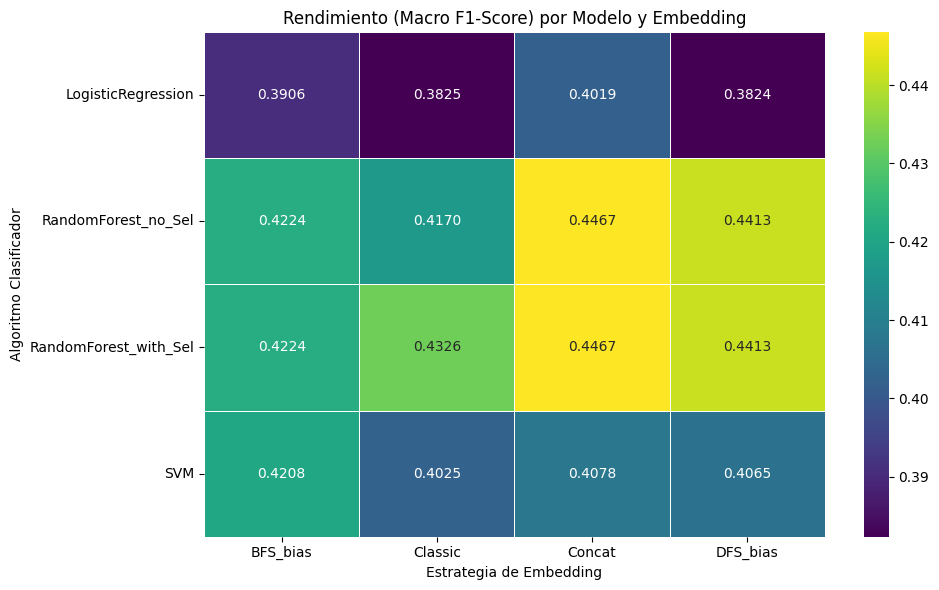

In [12]:
pivot_f1 = df_classification_summary.pivot(index='Model', columns='Embedding', values='Macro_F1')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_f1, annot=True, cmap='viridis', fmt=".4f", linewidths=.5)
plt.title('Rendimiento (Macro F1-Score) por Modelo y Embedding')
plt.xlabel('Estrategia de Embedding')
plt.ylabel('Algoritmo Clasificador')
plt.tight_layout()
plt.show()

## 5. El Problema del Desbalance y SMOTE

**El rastro numérico del Desbalance:**
Al observar los resultados de nuestro *baseline múltiple*, notamos una diferencia constante entre el **Weighted F1** (~0.52 - 0.54) y el **Macro F1** (~0.42 - 0.44). 
* El *Weighted F1* es más alto porque está siendo arrastrado hacia arriba por las clases mayoritarias, donde el modelo acierta más.
* El *Macro F1* es más bajo porque calcula el promedio dando el mismo peso a todas las clases; las clases minoritarias (con muy bajo rendimiento) están hundiendo esta métrica.

Nos enfrentamos a un *Imbalance Ratio* de 29.33, lo que representa un desbalance crítico. Los modelos actuales, aunque utilicen `class_weight='balanced'`, están luchando en un espacio vectorial donde las clases raras son solo "puntos aislados".

Al aplicar **SMOTE (Synthetic Minority Over-sampling Technique)**, crearemos ejemplos sintéticos a lo largo de los segmentos de línea que unen a las enfermedades de las clases minoritarias en el espacio de 128 dimensiones. Esto expande las "islas" de las clases raras, permitiendo que algoritmos como Random Forest dibujen fronteras de decisión mucho más robustas sin ser devorados por la clase mayoritaria.

A continuación, aplicaremos SMOTE **solo al mejor escenario** (Random Forest con los embeddings `Concat`) para evaluar su impacto. Es fundamental asegurar que el sobremuestreo ocurra *dentro* de la validación cruzada y exclusivamente en los datos de entrenamiento, evitando así cometer *Data Leakage*.



In [21]:
print(f"\n{'='*55}")
print("Evaluando Mejor Escenario con SMOTE (Random Forest + Concat)")
print(f"{'='*55}")

# Utilizamos el mejor embedding (Concat) y nuestra variable objetivo
X_best = embeddings_filtered['Concat']
y_best = y_encoded

# Definimos el pipeline con imblearn para evitar Data Leakage
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    # Como vimos que la selección de variables es redundante para RF, no la incluimos
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))
])

# Validación cruzada estratificada rigurosa
cv_smote = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Predicciones out-of-fold para evaluación justa
y_pred_smote = cross_val_predict(smote_pipeline, X_best, y_best, cv=cv_smote, n_jobs=-1)

# Cálculo de métricas
macro_f1_smote = f1_score(y_best, y_pred_smote, average='macro')
weighted_f1_smote = f1_score(y_best, y_pred_smote, average='weighted')
balanced_acc_smote = balanced_accuracy_score(y_best, y_pred_smote)

print(f"Resultados Random Forest con SMOTE (Embedding Concat):")
print(f" - Macro F1: {macro_f1_smote:.4f}")
print(f" - Weighted F1: {weighted_f1_smote:.4f}")
print(f" - Balanced Accuracy: {balanced_acc_smote:.4f}\n")

# Extraer el resultado anterior (baseline) para comparar
baseline_rf_concat = df_classification_summary[
    (df_classification_summary['Embedding'] == 'Concat') & 
    (df_classification_summary['Model'] == 'RandomForest_no_Sel')
]

if not baseline_rf_concat.empty:
    print("Comparativa con Baseline (Sin SMOTE):")
    print(f" - Macro F1 (Baseline)       : {baseline_rf_concat.iloc[0]['Macro_F1']:.4f}  ->  Con SMOTE: {macro_f1_smote:.4f}")
    print(f" - Balanced Acc. (Baseline)  : {baseline_rf_concat.iloc[0]['Balanced_Acc']:.4f}  ->  Con SMOTE: {balanced_acc_smote:.4f}")


Evaluando Mejor Escenario con SMOTE (Random Forest + Concat)
Resultados Random Forest con SMOTE (Embedding Concat):
 - Macro F1: 0.4270
 - Weighted F1: 0.5196
 - Balanced Accuracy: 0.4355

Comparativa con Baseline (Sin SMOTE):
 - Macro F1 (Baseline)       : 0.4467  ->  Con SMOTE: 0.4270
 - Balanced Acc. (Baseline)  : 0.4498  ->  Con SMOTE: 0.4355


## 6. Conclusiones de la Fase de Clasificación

El análisis de los clasificadores entrenados sobre los distintos *embeddings* de la Red de Enfermedades Humanas permite extraer las siguientes conclusiones:

1. **La combinación de embeddings proporciona los mejores resultados**

   La representación concatenada (**DFS + BFS**) alcanzó el mejor rendimiento global, obteniendo un **Macro F1 de 0.4467** con Random Forest. Este resultado indica que la combinación de información local y estructural ofrece una representación más completa de las enfermedades que cualquiera de las dos estrategias por separado.

2. **DFS supera a BFS en Random Forest**

   Considerando cada representación de forma independiente, los *embeddings* **DFS** obtienen mejores resultados que los **BFS** (Macro F1 de **0.441** frente a **0.422**). Esto sugiere que la información derivada de las relaciones locales entre enfermedades es más útil para la clasificación que la basada únicamente en similitudes estructurales.

3. **La selección de características no aporta mejoras relevantes**

   Los resultados obtenidos con y sin selección de variables son prácticamente equivalentes. Esto confirma la capacidad de Random Forest para identificar automáticamente las características más informativas durante el entrenamiento.

4. **SVM obtiene su mejor desempeño con BFS**

   A diferencia de Random Forest, el clasificador **SVM** alcanza su mejor resultado utilizando *embeddings* **BFS**, con una **Balanced Accuracy de 0.4511**. Este comportamiento sugiere que la información estructural genera espacios latentes más favorables para la separación lineal entre clases.

5. **SMOTE reduce el rendimiento**

   La aplicación de **SMOTE** no mejora los resultados pese al desbalance de clases existente. Por el contrario, el **Macro F1** disminuye hasta **0.4270**, lo que indica que la generación sintética de muestras introduce ruido y dificulta la separación entre categorías.

**Conclusión global**

Los resultados muestran que la estrategia más robusta consiste en combinar los *embeddings* DFS y BFS, aprovechando simultáneamente información local y estructural de la red. Además, mientras Random Forest obtiene mejores resultados con representaciones basadas en vecindad, SVM se beneficia más de la información estructural. Finalmente, el uso de los *embeddings* originales resulta preferible a la aplicación de técnicas de sobremuestreo como SMOTE.

